In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df1 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [ ]:
df1.columns = df1.columns.str.strip()


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   267 non-null    object 
 1   Date                                     267 non-null    object 
 2   Frequency                                267 non-null    object 
 3   Estimated Unemployment Rate (%)          267 non-null    float64
 4   Estimated Employed                       267 non-null    int64  
 5   Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                 267 non-null    object 
 7   longitude                                267 non-null    float64
 8   latitude                                 267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [74]:
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [75]:
print(df1.isnull().sum())


Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [ ]:
print(df1.describe())

       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       267.000000        2.670000e+02   
mean                         12.236929        1.396211e+07   
std                          10.803283        1.336632e+07   
min                           0.500000        1.175420e+05   
25%                           4.845000        2.838930e+06   
50%                           9.650000        9.732417e+06   
75%                          16.755000        2.187869e+07   
max                          75.850000        5.943376e+07   

       Estimated Labour Participation Rate (%)   longitude    latitude  
count                               267.000000  267.000000  267.000000  
mean                                 41.681573   22.826048   80.532425  
std                                   7.845419    6.270731    5.831738  
min                                  16.770000   10.850500   71.192400  
25%                                  37.265000   18.112400   76.085600  
50%

In [77]:
df1['Date'] = pd.to_datetime(df1['Date'].str.strip(), format='%d-%m-%Y')
df1['Month_Name'] = df1['Date'].dt.strftime('%B')
df1_monthly = df1.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

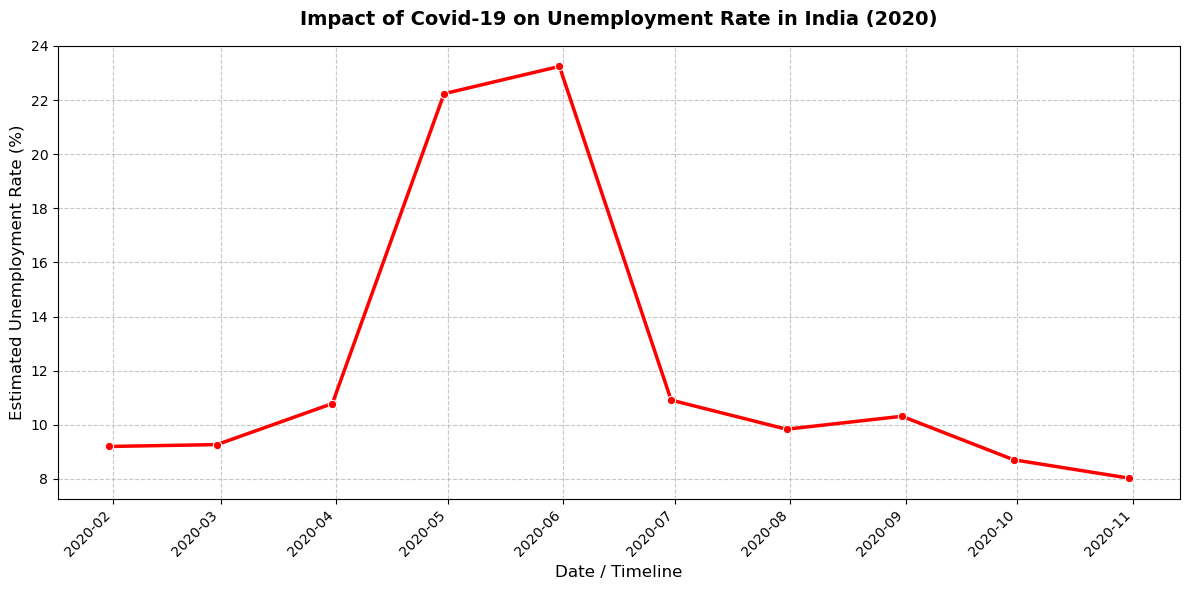

In [78]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df1_monthly, x='Date', y='Estimated Unemployment Rate (%)', marker='o', color='red', linewidth=2.5)
plt.xticks(rotation=45, ha='right')
plt.title('Impact of Covid-19 on Unemployment Rate in India (2020)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date / Timeline', fontsize=12)
plt.ylabel('Estimated Unemployment Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

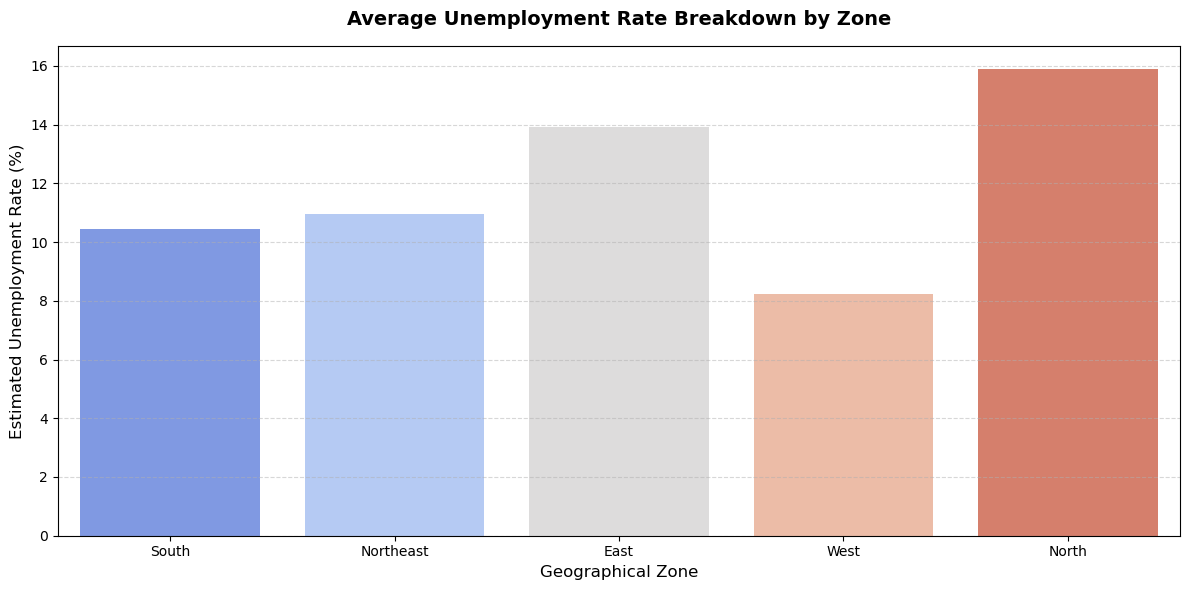

In [79]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df1, x='Region.1', y='Estimated Unemployment Rate (%)', hue='Region.1', legend=False, errorbar=None, palette='coolwarm')
plt.title('Average Unemployment Rate Breakdown by Zone', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Geographical Zone', fontsize=12)
plt.ylabel('Estimated Unemployment Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()